#### Analysis 1 

In [1]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
import os

In [2]:
fold = 0
exp_path = "./experiments/troubleshooting/20260227_103603"
fold_path = os.path.join(exp_path, "fold_" + str(fold))

<Axes: >

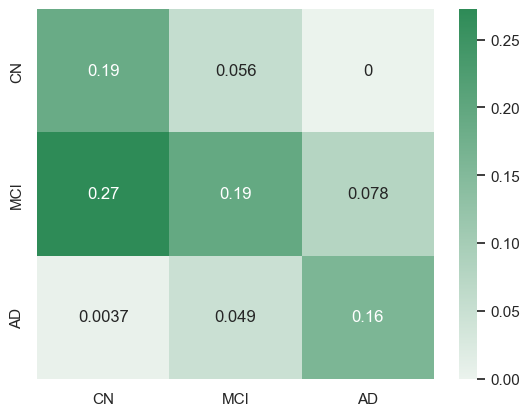

In [ ]:
# Confusion matrix
cm = pd.read_csv(os.path.join(fold_path, "confusion_matrix.csv"), index_col=0)

lbls = ["CN", "MCI", "AD"]
cm.index = lbls
cm.columns = lbls

cmap = sn.light_palette('seagreen', as_cmap=True)
sn.heatmap(cm/cm.sum().sum(), annot=True, cmap=cmap)


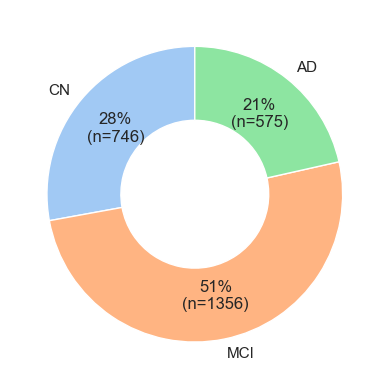

In [21]:
# Diagnosis distribution

sn.set_theme(palette='pastel')
samples = pd.read_csv(os.path.join(exp_path, "samples.csv"))
diag_dist = samples.groupby("label")["PET"].nunique()

def autopct_format(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.0f}%\n(n={count})'
    return inner

plt.pie(
    diag_dist,
    labels=["CN", "MCI", "AD"],
    startangle=90,
    wedgeprops=dict(width=0.5),
    autopct=autopct_format(diag_dist),
    pctdistance=0.7
)
plt.show()

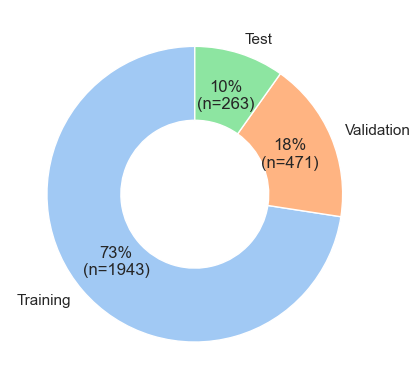

In [22]:
# Train, validation and test splits

sn.set_theme(palette='pastel')

splits = [ 4327, 1050, 586]
lbls = ["Training", "Validation", "Test"]

def autopct_format(values):
    def inner(pct):
        total = sum(values)
        count = int(round(pct * total / 100.0))
        return f'{pct:.0f}%\n(n={count})'
    return inner

plt.pie(
    splits,
    labels=lbls,
    startangle=90,
    wedgeprops=dict(width=0.5),
    autopct=autopct_format(diag_dist),
    pctdistance=0.7
)
plt.show()


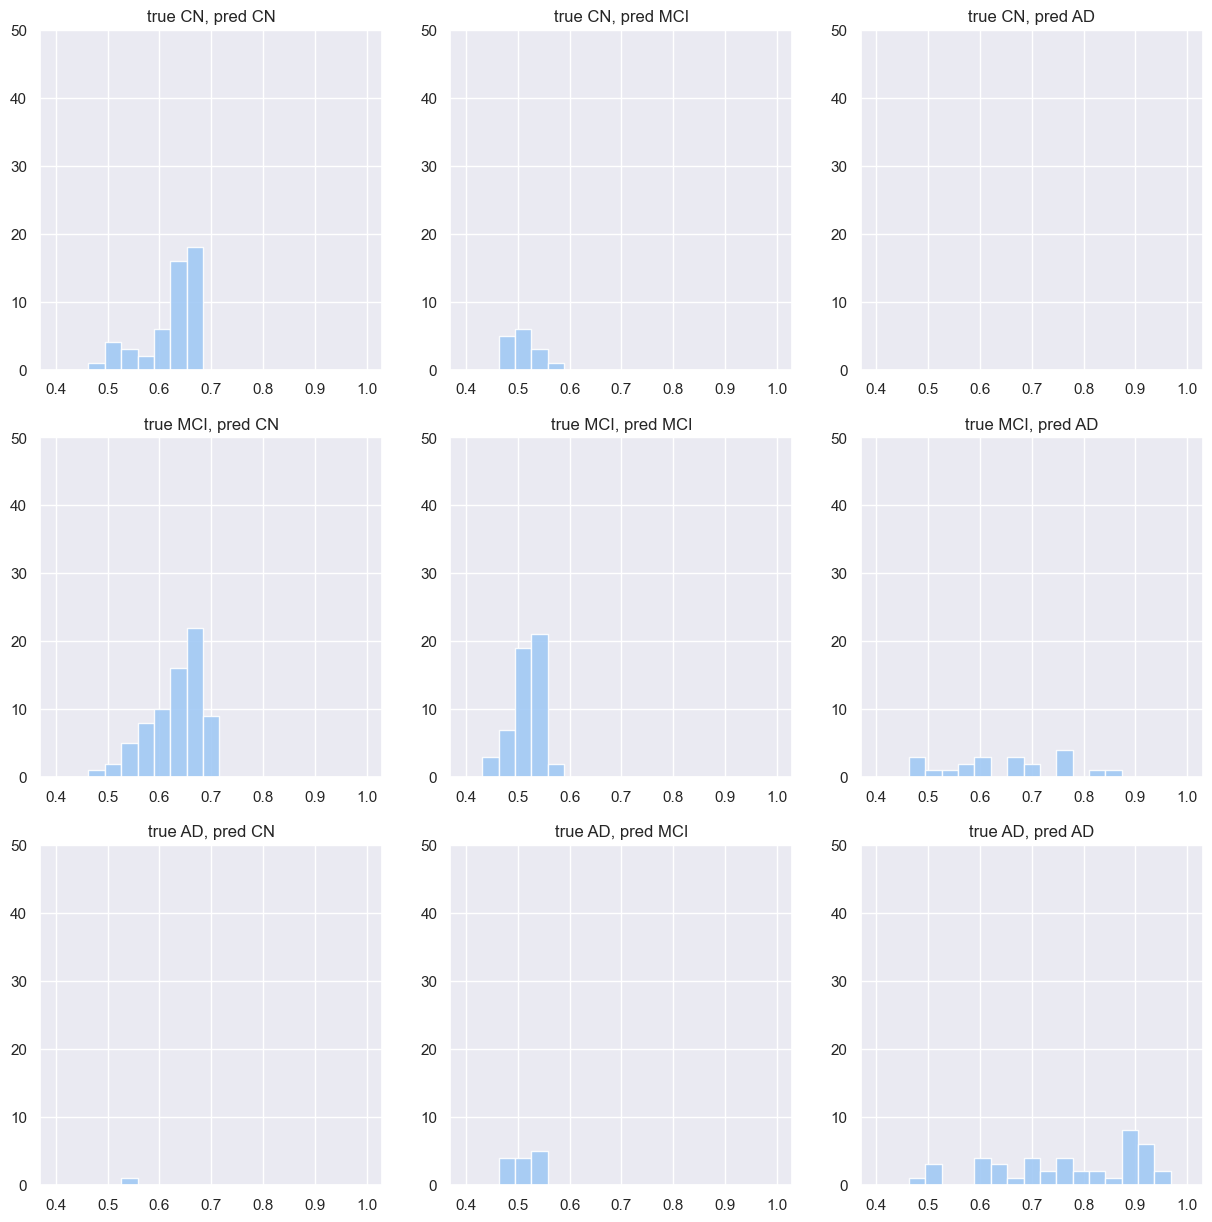

In [23]:
# Confidence distributions 

preds = pd.read_csv(os.path.join(fold_path, "predictions.csv"))

lbls = ["CN", "MCI", "AD"]

fig, axes = plt.subplots(3,3, figsize=(15,15))

for i in range(3):
    for j in range(3):

        axes[i,j].set_title(f"true {lbls[i]}, pred { lbls[j] }")
        axes[i,j].hist( 
            preds[ (preds["target"] == i) & (preds["pred"] == j) ]["confidence"], 
            bins=np.linspace(0.4,1,20),
            alpha=0.9, 
            cumulative=False)
        
        axes[i,j].set_ylim([0,50])



In [3]:
import torch
import json 
import yaml

from pkg.utils.instantiate import instantiate
from pkg.training.criterion import build_criterion

In [4]:
# Read config 
with open(os.path.join(exp_path, "config.yaml")) as f:
    cfg = yaml.safe_load(f)

print(cfg)

{'datamodule': {'class': 'pkg.data.datamodules.ADNITestDataModule', 'args': {'complete_only': True, 'data': {'data_dir': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/data/', 'scan_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/dataset_multimodal.csv', 'diagnostic_csv': '/project/aereditato/cestari/adni-mri-classification/data/preprocessing_multimodal/csv/DXSUM_02Feb2026.csv', 'diagnosis': [1, 2, 3], 'tolerance': 180, 'modalities': {'PET': ['PET-FDG'], 'MRI': ['MRI-T1-3T', 'MRI-T1-1.5T']}}, 'split': {'mode': 'holdout', 'seed': 42, 'folds': 5, 'test_size': 0.1, 'val_size': 0.2}, 'loader': {'batch_size': 8, 'weighted_sampling': False, 'shuffle': True}, 'transform': [{'random_flip': {'p': 0.5}}, {'random_affine': {'p': 0.5, 'degrees': 5, 'translation': 5}}, {'random_noise': {'p': 0.2, 'std': [0, 0.1]}}, {'random_blur': {'p': 1, 'std': 0.8}}]}}, 'model': {'class': 'pkg.models.poe.PoE', 'args': {'n_modalities

In [5]:
dm = instantiate(cfg["datamodule"])
dm.setup()
dm.set_fold(fold)

/home/cestari/.conda/envs/adni_rcc/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Matching scans to diagnoses...
Verifying scans available in dir...
Creating multimodal samples...


In [7]:
model = instantiate(cfg["model"])
criterion = build_criterion(cfg["criterion"], train_labels=dm.train_labels)

model.set_criterion(criterion)
best_state = torch.load( os.path.join(fold_path, "model.ckpt"), weights_only=True, map_location=torch.device('cpu'))
model.load_state_dict(best_state)

<All keys matched successfully>

In [8]:
from tqdm import tqdm

model.eval()

preds = []
targets = []
confs = []

for batch in tqdm(dm.test_dataloader()):

    out = model.test_batch(batch, 0)
    preds.append(out['preds'])
    targets.append(out['targets'])
    confs.append(out['confs'])

# Compute global confusion matrix and classification report
preds = torch.cat(preds).numpy()
targets = torch.cat(targets).numpy()
confs = torch.cat(confs).numpy()


  0%|          | 0/244 [00:00<?, ?it/s]

 25%|██▌       | 61/244 [00:48<03:06,  1.02s/it]

: 

### Analysis 2

In [3]:
import seaborn as sn
import pandas as pd
import matplotlib.pyplot as plt
import os

In [6]:
exp_path = "./experiments/pet_fdg_baseline/20260301_171206"

In [14]:
cm_sum = None

# Average confusion matrices
for fold in range(5):
    
    fold_path = os.path.join(exp_path, "fold_" + str(fold))

    cm = pd.read_csv(os.path.join(fold_path, "confusion_matrix.csv"), index_col=0)

    if fold == 0:
        cm_sum = cm
    else:
        cm_sum += cm

cm_avg = cm_sum / cm_sum.sum().sum()


<Axes: >

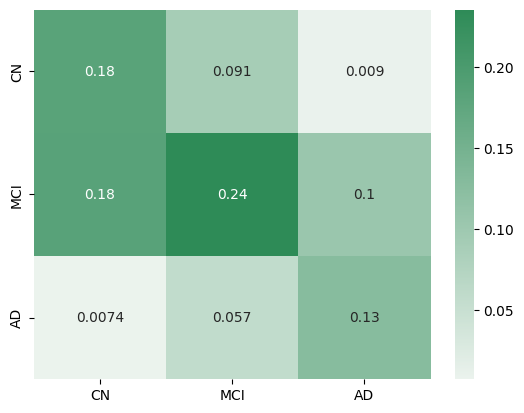

In [15]:
lbls = ["CN", "MCI", "AD"]
cm_avg.index = lbls
cm_avg.columns = lbls

cmap = sn.light_palette('seagreen', as_cmap=True)
sn.heatmap(cm_avg, annot=True, cmap=cmap)